In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

# Suppress technical warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=sm.tools.sm_exceptions.ConvergenceWarning)

# --- LOAD DATA ---
file_path = r"C:\Users\bazrafka\Desktop\counting\DiscussionPaperData\Python\Ali_Data_kg_ha_updated.xlsx"
df = pd.read_excel(file_path)

# Ensure categorical types for model factors
for col in ['ENTRY', 'REP', 'IBLK', 'Experiment Name']:
    if col in df.columns:
        df[col] = df[col].astype('category')

traits = ['CWT_A', 'CorrectedYield']
global_results = []

# --- CALCULATION ---
for exp_name, group_data in df.groupby('Experiment Name', observed=False):
    # Minimum threshold for a valid statistical model
    if len(group_data) < 10: 
        continue
        
    for trait in traits:
        if trait not in group_data.columns:
            continue
            
        analysis_data = group_data.copy().dropna(subset=[trait])
        
        try:
            # 1. Define Formula based on available factors
            fixed_parts = ["C(ENTRY)"]
            if analysis_data['REP'].nunique() > 1:
                fixed_parts.append("C(REP)")
            
            formula = f"Q('{trait}') ~ " + " + ".join(fixed_parts)
            
            # 2. Fit Mixed Model (incorporating IBLK as a random effect)
            # groups=REP identifies the blocks, re_formula defines the random intercept for IBLK
            model = smf.mixedlm(formula, analysis_data, groups=analysis_data["REP"], re_formula="~0 + C(IBLK)")
            result = model.fit(method=["lbfgs"], maxiter=10000)
            
            # 3. Extract MSE (Scale) and Mean to calculate CV
            mse = result.scale 
            mean_val = analysis_data[trait].mean()
            cv_value = (np.sqrt(mse) / mean_val) * 100
            
            global_results.append({
                'Experiment': exp_name,
                'Trait': trait,
                'Global_CV': round(cv_value, 2),
                'Mean': round(mean_val, 2),
                'n_plots': len(analysis_data)
            })
            
        except Exception:
            # Fallback to simple OLS if the Mixed Model fails to converge
            try:
                ols_formula = f"Q('{trait}') ~ C(ENTRY) + C(REP)" if analysis_data['REP'].nunique() > 1 else f"Q('{trait}') ~ C(ENTRY)"
                ols_result = smf.ols(ols_formula, data=analysis_data).fit()
                cv_ols = (np.sqrt(ols_result.mse_resid) / analysis_data[trait].mean()) * 100
                
                global_results.append({
                    'Experiment': exp_name,
                    'Trait': trait,
                    'Global_CV': round(cv_ols, 2),
                    'Mean': round(analysis_data[trait].mean(), 2),
                    'n_plots': len(analysis_data)
                })
            except:
                continue

# --- OUTPUT ---
if global_results:
    final_df = pd.DataFrame(global_results)
    final_df.to_excel("Global_CV_Analysis.xlsx", index=False)
    print("\n--- Global CV Report ---")
    print(final_df[['Experiment', 'Trait', 'Global_CV', 'n_plots']])

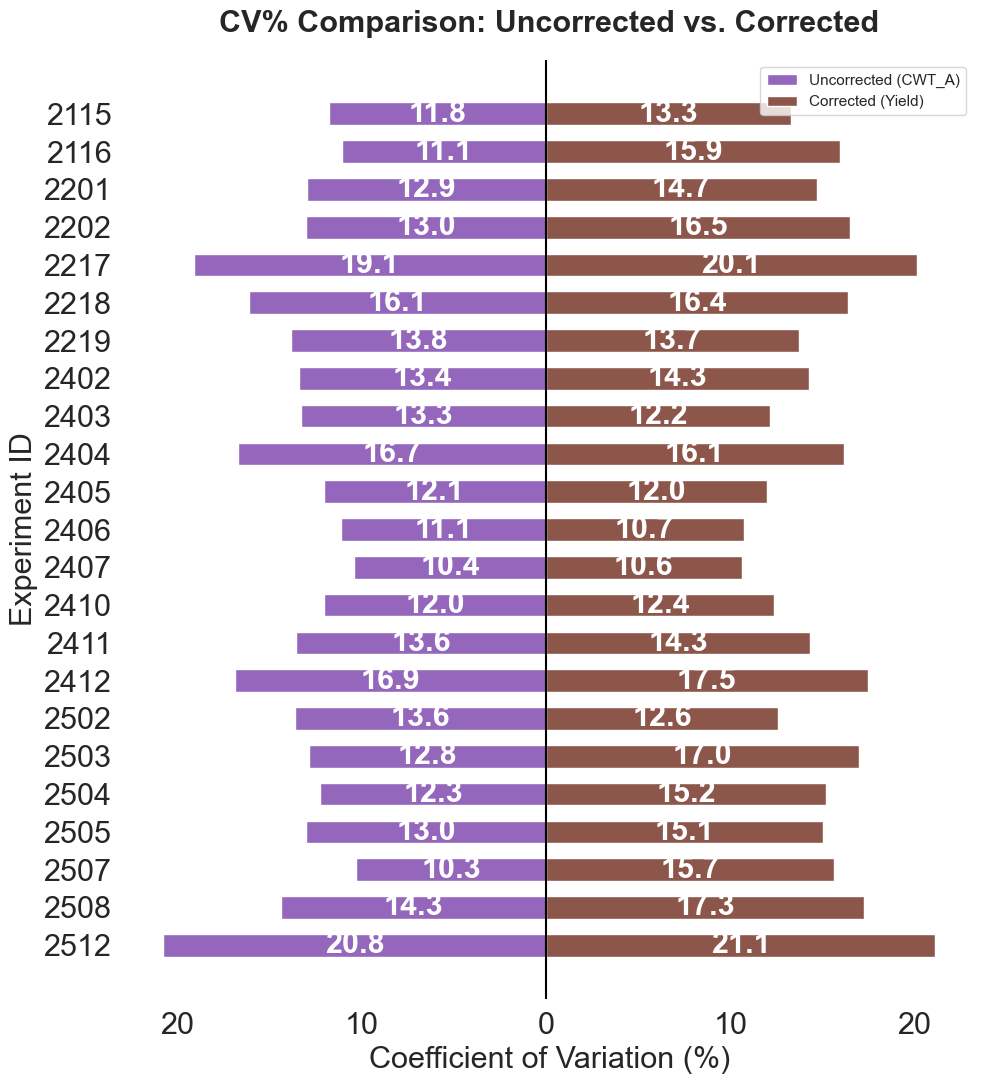

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator

# --- DATA PREPARATION ---
# Pivot and rename as before
plot_data = final_df.pivot(index='Experiment', columns='Trait', values='Global_CV').reset_index()
plot_data = plot_data.rename(columns={
    'CWT_A': 'Uncorrected_CV',
    'CorrectedYield': 'Corrected_CV',
    'Experiment': 'Trial'
}).dropna()

# !!! CRITICAL FIX: Convert Trial to string so they are treated as categories, not numbers
plot_data['Trial'] = plot_data['Trial'].astype(str)

# Sort them (optional: sort by value or name)
plot_data = plot_data.sort_values('Trial', ascending=False)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 11))
sns.set_theme(style="white")
ax = plt.gca()

left_data = plot_data['Uncorrected_CV'].values
right_data = plot_data['Corrected_CV'].values
trials = plot_data['Trial'].values

# Increased 'height' makes the bars thicker and fills the vertical space better
bar_height = 0.6 

# Plotting the bars
ax.barh(trials, -left_data, color='#9467bd', height=bar_height, label='Uncorrected (CWT_A)')
ax.barh(trials, right_data, color='#8c564b', height=bar_height, label='Corrected (Yield)')

# Add the center line
ax.axvline(0, color='black', linewidth=1.5)

# Formatting
ax.set_title('CV% Comparison: Uncorrected vs. Corrected', fontsize=22, pad=20, fontweight='bold')
ax.set_xlabel('Coefficient of Variation (%)', fontsize=22)
ax.set_ylabel('Experiment ID', fontsize=22)

# Add labels inside the bars
for i, (l, r) in enumerate(zip(left_data, right_data)):
    # Only show text if the bar is wide enough to fit it
    if l > 1:
        ax.text(-l/2, i, f"{l:.1f}", va='center', ha='center', color='white', fontweight='bold', fontsize=22)
    if r > 1:
        ax.text(r/2, i, f"{r:.1f}", va='center', ha='center', color='white', fontweight='bold', fontsize=22)

# Fix X-axis ticks to show absolute values
ticks = ax.get_xticks()
ax.xaxis.set_major_locator(FixedLocator(ticks))
ax.set_xticklabels([f"{abs(x):.0f}" for x in ticks])
# 2. Axis Tick Labels (The numbers and experiment IDs)
ax.tick_params(axis='both', which='major', labelsize=22)
# Clean up spines and legend
ax.legend(loc='upper right', frameon=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('GlobalcCV.png',dpi = 350)
plt.show()